# Customer Segmentation (Machine Learning)

In [17]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
customer = pd.read_csv("../data/processed/customer_summary.csv")
customer.head()

,customer_id,total_orders,avg_order_value,avg_rating,ratings_given
0,000285ae83ecf06a92b936d4f5b74342edb0e1940e1f00...,3,453.6000,5.0,1.0
1,00062fa202370fdd3076b794ec9358f36e35469bb8e5ff...,1,628.9500,NaN,NaN
2,001ab5fc3ee158b4d22e106897cee9b355e6eed50f163e...,1,1332.4000,NaN,NaN
3,001fdf2511dd137361424c9c15ea54774476691ceec5fa...,1,1352.4000,NaN,NaN
4,002afbd83626f0c699892fcb07b2ddf3858911482647b6...,4,805.6225,NaN,NaN


In [19]:
customer.columns

Index(['customer_id', 'total_orders', 'avg_order_value', 'avg_rating',
       'ratings_given'],
      dtype='object')

In [20]:
customer.isna().sum()

customer_id           0
total_orders          0
avg_order_value       0
avg_rating         9761
ratings_given      9761
dtype: int64

In [ ]:
customer['avg_rating'] = customer['avg_rating'].fillna(customer['avg_rating'].median())

customer_id           0
total_orders          0
avg_order_value       0
avg_rating            0
ratings_given      9761
cluster               0
dtype: int64

In [29]:
features = customer[['total_orders','avg_order_value','avg_rating']]

In [30]:
features.head()

,total_orders,avg_order_value,avg_rating
0,3,453.6000,5.0
1,1,628.9500,5.0
2,1,1332.4000,5.0
3,1,1352.4000,5.0
4,4,805.6225,5.0


In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

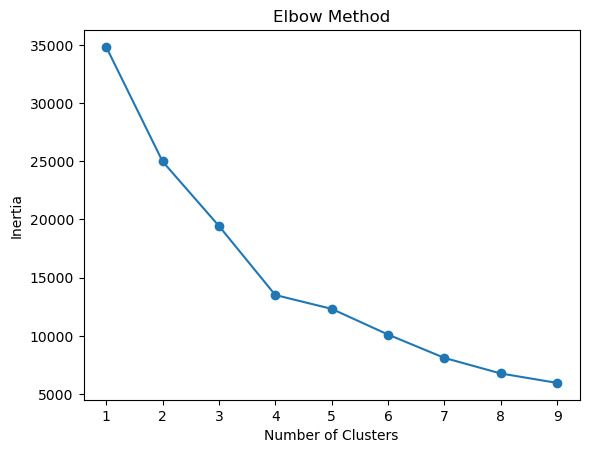

In [32]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [33]:
kmeans = KMeans(n_clusters=4, random_state=42)
customer['cluster'] = kmeans.fit_predict(X_scaled)
customer.head()

,customer_id,total_orders,avg_order_value,avg_rating,ratings_given,cluster
0,000285ae83ecf06a92b936d4f5b74342edb0e1940e1f00...,3,453.6000,5.0,1.0,0
1,00062fa202370fdd3076b794ec9358f36e35469bb8e5ff...,1,628.9500,5.0,NaN,0
2,001ab5fc3ee158b4d22e106897cee9b355e6eed50f163e...,1,1332.4000,5.0,NaN,2
3,001fdf2511dd137361424c9c15ea54774476691ceec5fa...,1,1352.4000,5.0,NaN,2
4,002afbd83626f0c699892fcb07b2ddf3858911482647b6...,4,805.6225,5.0,NaN,0


In [36]:
cluster_summary = customer.groupby('cluster').mean(numeric_only=True)
cluster_summary

,total_orders,avg_order_value,avg_rating,ratings_given
cluster,,,,
0,1.453680,559.345384,4.972051,1.247016
1,1.898204,609.468414,1.881238,1.059880
2,1.461308,1472.672223,4.982603,1.142157
3,7.767305,624.507209,4.902977,2.493151


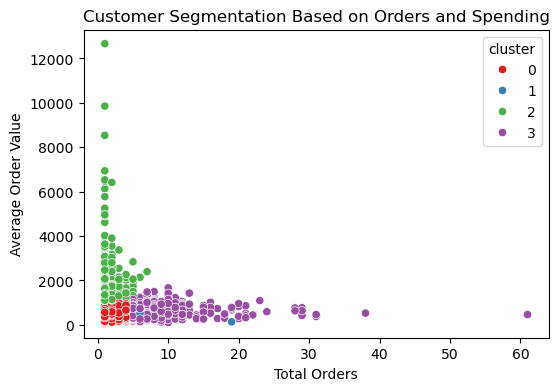

In [39]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=customer,
    x='total_orders',
    y='avg_order_value',
    hue='cluster',
    palette='Set1'
)

plt.title("Customer Segmentation Based on Orders and Spending")
plt.xlabel("Total Orders")
plt.ylabel("Average Order Value")

plt.show()

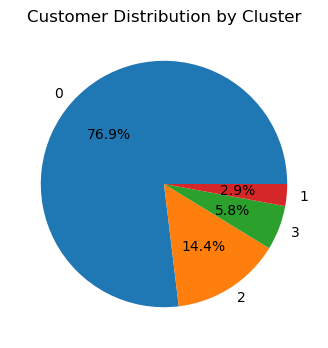

In [43]:
plt.figure(figsize=(6,4))

customer['cluster'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Customer Distribution by Cluster")
plt.ylabel("")

plt.show()

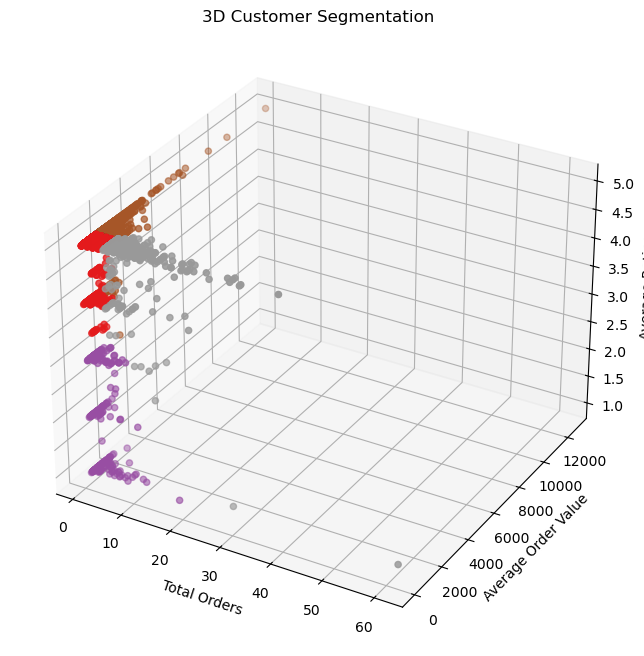

In [47]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    customer['total_orders'],
    customer['avg_order_value'],
    customer['avg_rating'],
    c=customer['cluster'],
    cmap='Set1'
)

ax.set_xlabel('Total Orders')
ax.set_ylabel('Average Order Value')
ax.set_zlabel('Average Rating')

ax.set_title("3D Customer Segmentation")

plt.show()

In [44]:
customer.to_csv("customer_clusters.csv", index=False)

# Delivery Delay Prediction (Classification)

In [67]:
orders['delayed'] = (orders['kpt_duration'] > 30).astype(int)

In [68]:
ml_data = orders[
[
'distance_km',
'item_count',
'bill_subtotal',
'packaging_charges',
'total',
'rider_wait_time',
'delayed'
]
]

In [69]:
ml_data = ml_data.dropna()
ml_data.shape

(21153, 7)

In [70]:
X = ml_data.drop('delayed', axis=1)
y = ml_data['delayed']

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
LogisticRegression(class_weight='balanced')

LogisticRegression(class_weight='balanced')

In [78]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [79]:
y_pred = model.predict(X_test)

In [80]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[3324  748]
 [  43  116]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.89      4072
           1       0.13      0.73      0.23       159

    accuracy                           0.81      4231
   macro avg       0.56      0.77      0.56      4231
weighted avg       0.96      0.81      0.87      4231



In [81]:
orders['delayed'].value_counts()

delayed
0    20534
1      787
Name: count, dtype: int64

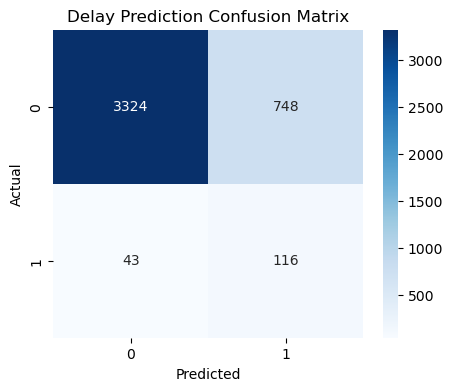

In [82]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Delay Prediction Confusion Matrix")

plt.show()

The confusion matrix shows that the model correctly identifies the majority of delayed orders. Out of 159 delayed orders, 116 were successfully detected, resulting in a recall of approximately 73%. Although the model produces some false delay predictions, early identification of delays can help delivery platforms notify customers in advance and optimize rider allocation.

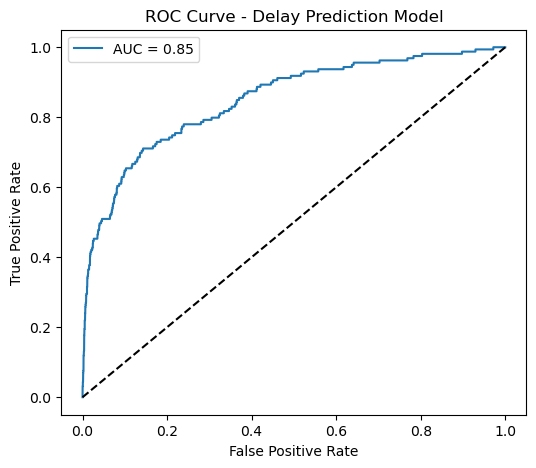

In [83]:
from sklearn.metrics import roc_curve, roc_auc_score

# predicted probabilities
y_prob = model.predict_proba(X_test)[:,1]

# compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1],[0,1],'k--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Delay Prediction Model")

plt.legend()

plt.show()

ROC Curve Analysis

The ROC curve evaluates the model's ability to distinguish between delayed and non-delayed orders. The AUC score measures the overall classification performance. A higher AUC indicates better separation between the two classes. This helps assess whether the model can reliably identify orders likely to experience delays.